# 08 - FD001 error analysis and decision metrics

Objetivo: comparar los modelos de FD001, analizar errores peligrosos y producir
las predicciones del mejor modelo sobre el test oficial FD001.

El mejor modelo se elige solo con validacion artificial. El test oficial se usa
al final para reporte, no para elegir hiperparametros.

In [ ]:
RUN_OFFICIAL_TEST = False


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessed_FD001 import (
    DEFAULT_RUL_CAP,
    DEFAULT_TEMPORAL_WINDOW,
    prepare_fd001_current_cycle_full_train_for_test,
    prepare_fd001_temporal_full_train_for_test,
)
from src.fd001_modeling import (
    fd001_model_factories,
    metrics_by_model,
    metrics_by_rul_bin,
    official_test_prediction_frame,
    regression_metrics,
)

RESULTS_DIR = PROJECT_ROOT / "results" / "FD001"
PREDICTIONS_DIR = PROJECT_ROOT / "predictions"
CONFIG_DIR = PROJECT_ROOT / "configs"
FIGURE_DIR = PROJECT_ROOT / "figures" / "fd001_decision"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Carga de resultados de validacion

In [2]:
current_metrics = pd.read_csv(RESULTS_DIR / "fd001_current_cycle_metrics.csv")
temporal_metrics = pd.read_csv(RESULTS_DIR / "fd001_temporal_metrics.csv")
current_predictions = pd.read_csv(RESULTS_DIR / "fd001_current_cycle_validation_predictions.csv")
temporal_predictions = pd.read_csv(RESULTS_DIR / "fd001_temporal_validation_predictions.csv")

all_metrics = pd.concat([current_metrics, temporal_metrics], ignore_index=True)
all_predictions = pd.concat([current_predictions, temporal_predictions], ignore_index=True)

all_metrics = all_metrics.sort_values(["rmse", "mae"]).reset_index(drop=True)
all_metrics.to_csv(RESULTS_DIR / "fd001_combined_validation_metrics.csv", index=False)
all_predictions.to_csv(RESULTS_DIR / "fd001_combined_validation_predictions.csv", index=False)

display(all_metrics)

,representation,model_name,n_features,target_used_for_training,n_eval,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct
0,temporal_w30,RandomForestRegressor,119,RUL_capped,99,13.817341,17.912073,0.819898,580.933845,5.868019,14.141414
1,temporal_w30,MLP,119,RUL_capped,99,14.311264,18.734374,0.802983,633.588376,6.399883,15.151515
2,current_cycle,RandomForestRegressor,17,RUL_capped,99,16.669382,21.535607,0.739660,1386.500435,14.005055,16.161616
3,current_cycle,MLP,17,RUL_capped,99,16.389131,22.074671,0.726464,1500.262156,15.154163,16.161616
4,temporal_w30,Ridge,119,RUL_capped,99,18.419013,23.133112,0.699604,1073.335072,10.841768,17.171717
5,current_cycle,Ridge,17,RUL_capped,99,19.620435,24.014162,0.676286,1167.119272,11.789084,24.242424
6,current_cycle,DummyRegressor,17,RUL_capped,99,37.233689,42.879812,-0.032124,18169.638789,183.531705,40.404040


## Errores por rango de RUL

,representation,model_name,rul_bin,n_eval,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct
23,temporal_w30,RandomForestRegressor,0-30,20,3.683619,4.183181,0.000000,8.942007,0.447100,0.0
27,temporal_w30,MLP,0-30,20,3.642363,5.147425,0.000000,10.741952,0.537098,0.0
12,current_cycle,MLP,0-30,20,5.978268,8.235149,0.000000,23.915824,1.195791,5.0
8,current_cycle,RandomForestRegressor,0-30,20,7.899243,9.553294,0.000000,31.261242,1.563062,5.0
19,temporal_w30,Ridge,0-30,20,13.498600,16.088914,0.000000,99.776282,4.988814,15.0
4,current_cycle,Ridge,0-30,20,16.933905,20.187123,0.000000,168.429223,8.421461,45.0
0,current_cycle,DummyRegressor,0-30,20,66.958819,66.958819,0.000000,16161.342577,808.067129,100.0
22,temporal_w30,RandomForestRegressor,30-60,20,12.365219,16.912432,0.000000,174.620796,8.731040,20.0
26,temporal_w30,MLP,30-60,20,13.102543,17.721013,0.000000,142.447820,7.122391,20.0
18,temporal_w30,Ridge,30-60,20,19.078487,22.834680,0.000000,300.637103,15.031855,40.0


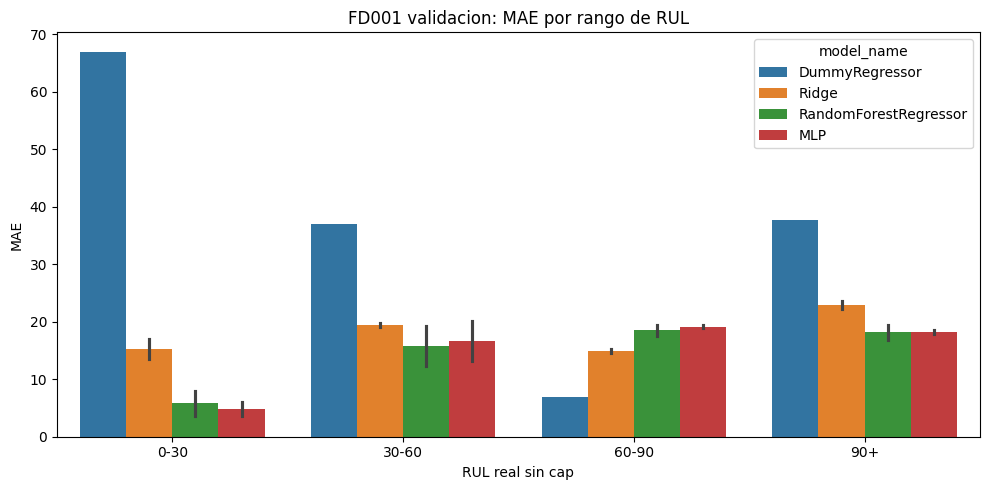

In [3]:
bin_metrics = metrics_by_rul_bin(all_predictions)
bin_metrics.to_csv(RESULTS_DIR / "fd001_combined_metrics_by_rul_bin.csv", index=False)
display(bin_metrics.sort_values(["rul_bin", "rmse"]))

plt.figure(figsize=(10, 5))
sns.barplot(data=bin_metrics, x="rul_bin", y="mae", hue="model_name")
plt.title("FD001 validacion: MAE por rango de RUL")
plt.xlabel("RUL real sin cap")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_mae_by_rul_bin.png", dpi=150)
plt.show()

## Errores peligrosos vs conservadores

Error peligroso: `prediccion - RUL_real > 20`.

Error conservador fuerte: `prediccion - RUL_real < -20`.

In [4]:
decision_summary = (
    all_predictions
    .groupby(["representation", "model_name"], as_index=False)
    .agg(
        n_eval=("unit", "count"),
        dangerous_error_pct=("dangerous_error", lambda s: s.mean() * 100),
        conservative_error_pct=("conservative_error", lambda s: s.mean() * 100),
        mean_error=("error", "mean"),
        median_abs_error=("abs_error", "median"),
    )
    .sort_values("dangerous_error_pct")
)
decision_summary.to_csv(RESULTS_DIR / "fd001_decision_error_summary.csv", index=False)
display(decision_summary)

,representation,model_name,n_eval,dangerous_error_pct,conservative_error_pct,mean_error,median_abs_error
5,temporal_w30,RandomForestRegressor,99,14.141414,15.151515,-0.048491,9.818445
4,temporal_w30,MLP,99,15.151515,17.171717,-0.538520,11.045189
1,current_cycle,MLP,99,16.161616,19.191919,0.154718,10.112749
2,current_cycle,RandomForestRegressor,99,16.161616,18.181818,0.619338,13.487664
6,temporal_w30,Ridge,99,17.171717,21.212121,-0.169610,15.623191
3,current_cycle,Ridge,99,24.242424,19.191919,0.985052,16.957040
0,current_cycle,DummyRegressor,99,40.404040,39.393939,7.564880,36.958819


## Seleccion del mejor modelo y evaluacion en test oficial protegida

La seleccion previa usa RMSE de validacion artificial. La evaluacion oficial queda bloqueada por `RUN_OFFICIAL_TEST = False` para que este notebook no se use accidentalmente durante busqueda o tuning.


In [5]:
if not RUN_OFFICIAL_TEST:
    print("RUN_OFFICIAL_TEST = False. Se omite la evaluacion en test oficial en este notebook.")
    official_predictions = None
    official_metrics = None
else:
    best = all_metrics.sort_values(["rmse", "mae"]).iloc[0]
    best_representation = best["representation"]
    best_model_name = best["model_name"]

    if best_representation == "current_cycle":
        final_prepared = prepare_fd001_current_cycle_full_train_for_test(
            max_rul=DEFAULT_RUL_CAP,
        )
        include_dummy = True
    else:
        final_prepared = prepare_fd001_temporal_full_train_for_test(
            max_rul=DEFAULT_RUL_CAP,
            window_size=DEFAULT_TEMPORAL_WINDOW,
        )
        include_dummy = False

    factories = fd001_model_factories(
        random_state=RANDOM_STATE,
        include_dummy=include_dummy,
    )
    final_model = factories[best_model_name]()
    final_model.fit(final_prepared["X_train"], final_prepared["y_train"])

    official_predictions = official_test_prediction_frame(
        final_prepared,
        final_model,
        model_name=best_model_name,
        representation=best_representation,
    )
    official_predictions.to_csv(PREDICTIONS_DIR / "fd001_best_model_predictions.csv", index=False)

    official_metrics = regression_metrics(
        official_predictions["y_true_rul_raw"],
        official_predictions["y_pred_rul"],
    )
    official_metrics = pd.DataFrame([
        {
            "representation": best_representation,
            "model_name": best_model_name,
            "n_test": len(official_predictions),
            **official_metrics,
        }
    ])
    official_metrics.to_csv(RESULTS_DIR / "fd001_official_test_metrics.csv", index=False)

    def to_builtin(value):
        if hasattr(value, "item"):
            return value.item()
        if isinstance(value, dict):
            return {str(k): to_builtin(v) for k, v in value.items()}
        if isinstance(value, (list, tuple)):
            return [to_builtin(v) for v in value]
        if isinstance(value, Path):
            return str(value)
        return value

    model_params = final_model.get_params() if hasattr(final_model, "get_params") else {
        "random_state": getattr(final_model, "random_state", RANDOM_STATE),
        "dropout": getattr(final_model, "dropout", None),
        "lr": getattr(final_model, "lr", None),
        "weight_decay": getattr(final_model, "weight_decay", None),
        "batch_size": getattr(final_model, "batch_size", None),
        "max_epochs": getattr(final_model, "max_epochs", None),
        "patience": getattr(final_model, "patience", None),
    }

    final_config = {
        "dataset": "NASA C-MAPSS FD001",
        "task": "Remaining Useful Life regression",
        "selection_policy": (
            "Best model selected by lowest RMSE on artificial-cutoff validation. "
            "Official test is used only once for final reporting."
        ),
        "preprocessing": {
            "rul_raw_definition": "max_cycle - cycle for train; RUL_FD001.txt for official test last cycle",
            "training_target": "RUL capped",
            "metric_target": "RUL_raw uncapped",
            "rul_cap": DEFAULT_RUL_CAP,
            "dropped_columns": final_prepared["dropped_columns"],
            "scaler": "StandardScaler fit on final training split only",
            "representation": best_representation,
            "window_size": final_prepared.get("window_size"),
            "base_feature_columns": final_prepared.get("base_feature_columns", final_prepared["feature_columns"]),
            "feature_columns": final_prepared["feature_columns"],
            "n_features": len(final_prepared["feature_columns"]),
        },
        "validation": {
            "split_policy": "complete engine units, never individual rows",
            "cut_ruls": [20, 50, 80, 110, 140],
            "cutoff_rule": "cut_cycle = max_cycle - cut_rul; skip if cut_cycle < 1",
            "n_validation_examples": int(best["n_eval"]),
        },
        "final_model": {
            "model_name": best_model_name,
            "model_params": model_params,
        },
        "validation_metrics": best.to_dict(),
        "official_test_metrics": official_metrics.iloc[0].to_dict(),
        "artifacts": {
            "predictions": str(PREDICTIONS_DIR / "fd001_best_model_predictions.csv"),
            "official_test_metrics": str(RESULTS_DIR / "fd001_official_test_metrics.csv"),
            "combined_validation_metrics": str(RESULTS_DIR / "fd001_combined_validation_metrics.csv"),
        },
    }

    config_path = CONFIG_DIR / "fd001_best_model_config.json"
    config_path.write_text(
        json.dumps(to_builtin(final_config), indent=2),
        encoding="utf-8",
    )

    print("Mejor modelo por validacion:", best_representation, best_model_name)
    print("Config guardada:", config_path)
    display(official_metrics)
    display(official_predictions.head())


Mejor modelo por validacion: temporal_w30 RandomForestRegressor
Config guardada: C:\Users\frane\udesa\ML\vs\TPF-ML\configs\fd001_best_model_config.json


,representation,model_name,n_test,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct
0,temporal_w30,RandomForestRegressor,100,12.853522,17.793269,0.816662,750.282702,7.502827,16.0


,unit,y_true_rul_raw,y_pred_rul,error,abs_error
0,1,112.0,122.501112,10.501112,10.501112
1,2,98.0,120.967297,22.967297,22.967297
2,3,69.0,40.984035,-28.015965,28.015965
3,4,82.0,119.481631,37.481631,37.481631
4,5,91.0,99.259540,8.259540,8.259540


## Ranking de prioridad de mantenimiento

Motores con menor RUL predicho quedan arriba. Este ranking debe interpretarse
como una herramienta de priorizacion, no como unica regla de decision.

,priority_rank,unit,y_true_rul_raw,y_pred_rul,error,abs_error
0,1,34,7.0,6.980361,-0.019639,0.019639
1,2,76,10.0,7.197469,-2.802531,2.802531
2,3,81,8.0,8.745996,0.745996,0.745996
3,4,68,8.0,9.559726,1.559726,1.559726
4,5,31,8.0,10.189124,2.189124,2.189124
5,6,82,9.0,10.776541,1.776541,1.776541
6,7,35,11.0,12.185255,1.185255,1.185255
7,8,42,10.0,12.298544,2.298544,2.298544
8,9,20,16.0,13.037399,-2.962601,2.962601
9,10,49,21.0,13.938726,-7.061274,7.061274


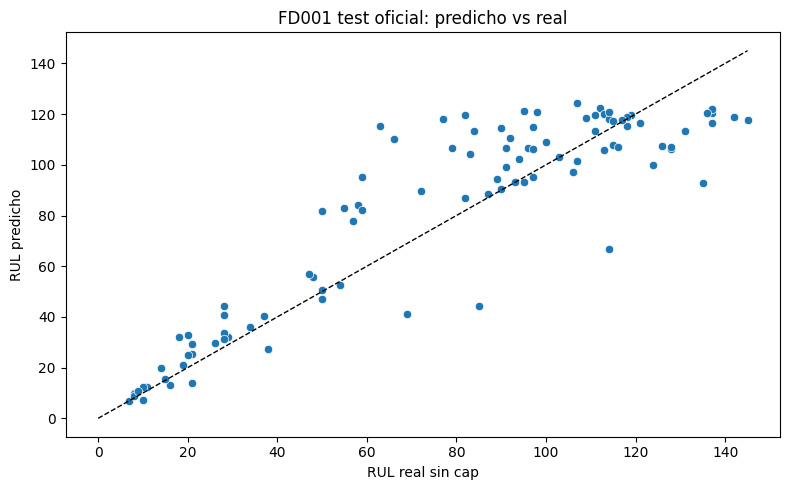

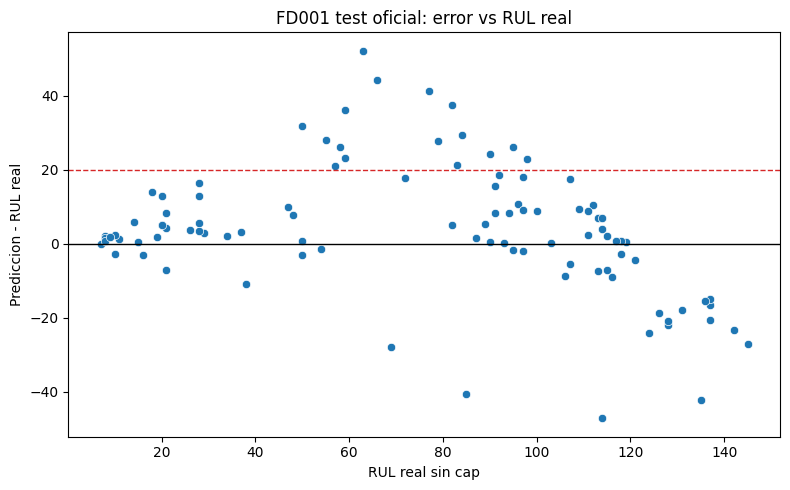

In [6]:
if official_predictions is None:
    print("Sin evaluacion oficial: no se genera ranking de prioridad ni figuras de test oficial.")
else:
    priority_ranking = (
        official_predictions
        .sort_values("y_pred_rul")
        .reset_index(drop=True)
    )
    priority_ranking.insert(0, "priority_rank", range(1, len(priority_ranking) + 1))
    priority_ranking.to_csv(RESULTS_DIR / "fd001_maintenance_priority_ranking.csv", index=False)

    display(priority_ranking.head(15))

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=official_predictions,
        x="y_true_rul_raw",
        y="y_pred_rul",
    )
    max_axis = max(official_predictions["y_true_rul_raw"].max(), official_predictions["y_pred_rul"].max())
    plt.plot([0, max_axis], [0, max_axis], color="black", linestyle="--", linewidth=1)
    plt.xlabel("RUL real sin cap")
    plt.ylabel("RUL predicho")
    plt.title("FD001 test oficial: predicho vs real")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "official_test_predicted_vs_true.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=official_predictions,
        x="y_true_rul_raw",
        y="error",
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.axhline(20, color="tab:red", linestyle="--", linewidth=1)
    plt.xlabel("RUL real sin cap")
    plt.ylabel("Prediccion - RUL real")
    plt.title("FD001 test oficial: error vs RUL real")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "official_test_error_vs_true_rul.png", dpi=150)
    plt.show()
